In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import archnemesis as ans
from archnemesis.database.datatypes.wave_range import WaveRange


# Define files used later

test_data_dir = Path("./test_data")
ANS_LINE_DATABASE_FILE = test_data_dir / "test_ld.h5"
ANS_CONTINUUM_DATABASE_FILE = test_data_dir / "test_pc.h5"
ANS_PARTITION_FUNCTION_DATABASE_FILE = test_data_dir / "hitran24_pf.h5"

In [2]:
gasID, isoID, ambient_gas = (
    ans.enum.GasEnum.CH4, 
    0,
    ans.enum.AmbientGasEnum.AIR,
)
#vmin, vmax = WaveRange(1.3, 3.5, ans.enum.WaveUnitEnum.Wavelength_um).as_unit(ans.enum.WaveUnitEnum.Wavenumber_cm).values()
vmin, vmax = WaveRange(0.001, 1000, ans.enum.WaveUnitEnum.Wavelength_um).as_unit(ans.enum.WaveUnitEnum.Wavenumber_cm).values()

print(f'{gasID=} {isoID=}')
print(f'{vmin=} {vmax=}')

gasID=<GasEnum.CH4: 6> isoID=0
vmin=10.0 vmax=10000000.0


In [3]:
# Create a LineData_0 instance and load the data we need

TEMPERATURE = 300

line_data = ans.LineData_0(
	ID=gasID,
	ISO=isoID,
	ambient_gasses=ambient_gas,
	LINE_DATABASE = ANS_LINE_DATABASE_FILE,
	CONTINUUM_DATABASE = ANS_CONTINUUM_DATABASE_FILE,
	PARTITION_FUNCTION_DATABASE = ANS_PARTITION_FUNCTION_DATABASE_FILE,
)

print(f'{line_data._params_fetched_lines_last=}')
print(f'{line_data._params_fetched_partition_last=}')

# Loading the line data in our required spectral range
line_data.set_params(vmin=vmin,vmax=vmax, temp_requested=TEMPERATURE).fetch_linedata()

# Loading the partition function data
line_data.fetch_partition_fn()

print(f'{line_data._params_fetched_lines_last=}')
print(f'{line_data._params_fetched_partition_last=}')

print(f'{len(line_data.line_data)=}')
print(f'{len(line_data.continuum_data)=}')

line_data._params_fetched_lines_last=False
line_data._params_fetched_partition_last=False
LineData_0::fetch_partition_fn()
Actually getting the partition function
AnsLineDataFile::get_data(...)
AnsLineDataFile :: target_line_set_params=(-1, 300)


INFO :: get_data :: ans_pseudo_continuum_file.py-537 :: Found compatible data for s_max=np.float64(1e-26) temperature=np.float64(300.0). Chosen group has leaf_grp_parameters=(np.float64(1e-26), np.float64(300.0), np.int64(1))


AnsLineDataFile::get_data(...)


AnsLineDataFile::get_data(...)
AnsLineDataFile::get_data(...)
single_iso_line_set_data.nu=array([  19.204034,   23.834724,   28.305003, ..., 4562.204505,
       4562.265841, 4562.277393])
pseudo_continuum_data=PseudoContinuumData(s_max=np.float64(1e-26), t_cont=np.float64(300.0), p_cont=np.int64(1), req_wn_range=(10.0, 10000000.0), wn_bin_center=array([5.000e+00, 1.500e+01, 2.500e+01, 3.500e+01, 4.500e+01, 5.500e+01,
       6.500e+01, 7.500e+01, 8.500e+01, 9.500e+01, 1.050e+02, 1.150e+02,
       1.250e+02, 1.350e+02, 1.450e+02, 1.550e+02, 1.650e+02, 1.750e+02,
       1.850e+02, 1.950e+02, 2.050e+02, 2.150e+02, 2.250e+02, 2.350e+02,
       2.450e+02, 2.550e+02, 2.650e+02, 2.750e+02, 2.850e+02, 2.950e+02,
       3.050e+02, 3.150e+02, 3.250e+02, 3.350e+02, 3.450e+02, 3.550e+02,
       3.650e+02, 3.750e+02, 3.850e+02, 3.950e+02, 4.050e+02, 4.150e+02,
       4.250e+02, 4.350e+02, 4.450e+02, 4.550e+02, 4.650e+02, 4.750e+02,
       4.850e+02, 4.950e+02, 5.050e+02, 5.150e+02, 5.250e+02, 5.350

len(line_strengths)=4
i=0 len(ld.NU)=180383 len(ls)=180383
i=1 len(ld.NU)=0 len(ls)=0
i=2 len(ld.NU)=0 len(ls)=0
i=3 len(ld.NU)=0 len(ls)=0


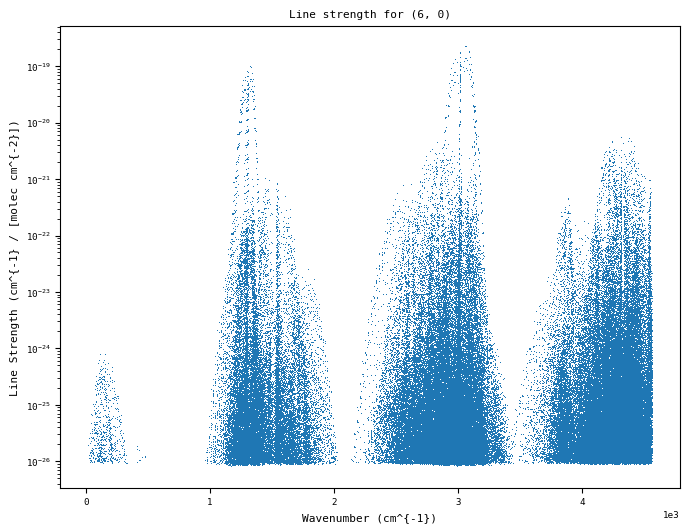

i=0 len(pc.WN_BIN_CENTER)=1000 len(pc.LINE_STRENGTH_SUM)=1000
i=1 len(pc.WN_BIN_CENTER)=0 len(pc.LINE_STRENGTH_SUM)=0
i=2 len(pc.WN_BIN_CENTER)=0 len(pc.LINE_STRENGTH_SUM)=0
i=3 len(pc.WN_BIN_CENTER)=0 len(pc.LINE_STRENGTH_SUM)=0


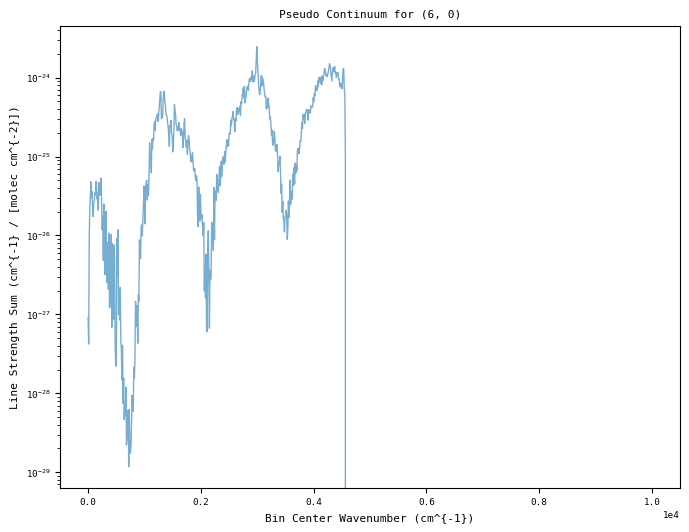

In [4]:
# Calculate line strengths and plot them #

line_strengths = line_data.calculate_line_strength(t_calc=TEMPERATURE)
print(f'{len(line_strengths)=}')


for i, (ld, ls) in enumerate(zip(line_data.line_data, line_strengths)):
	print(f'{i=} {len(ld.NU)=} {len(ls)=}')
	plt.plot(ld.NU, ls, ls='none', marker=',')
plt.title(f'Line strength for ({line_data.ID}, {line_data.ISO})')
plt.xlabel('Wavenumber (cm^{-1})')
plt.ylabel('Line Strength (cm^{-1} / [molec cm^{-2}])')
plt.yscale('log')
plt.show()

for i, pc in enumerate(line_data.continuum_data):
	print(f'{i=} {len(pc.WN_BIN_CENTER)=} {len(pc.LINE_STRENGTH_SUM)=}')
	plt.plot(pc.WN_BIN_CENTER, pc.LINE_STRENGTH_SUM, ls='-', lw=1, alpha=0.6, marker='None')
plt.title(f'Pseudo Continuum for ({line_data.ID}, {line_data.ISO})')
plt.xlabel('Bin Center Wavenumber (cm^{-1})')
plt.ylabel('Line Strength Sum (cm^{-1} / [molec cm^{-2}])')
plt.yscale('log')
plt.show()

INFO :: add_monochromatic_absorption :: LineData_0.py-2057 :: i=0 iso_line_data._data.shape=(11, 180383) iso_continuum_data._data.shape=(10, 1000)


iso_continuum_data=PseudoContSpecData(s_min=np.float64(1e-26), t_cont=np.float64(300.0), p_cont=np.int64(1), rt_gas_desc=RadtranGasDescriptor(gas_id=np.int64(6), iso_id=np.int64(1)), broadening_molecule_ids=(-1, 0), req_wn_range=(10.0, 10000000.0), _molecular_mass=16.0313, _data=array([[5.00000000e+00, 1.50000000e+01, 2.50000000e+01, ...,
        9.97500000e+03, 9.98500000e+03, 9.99500000e+03],
       [1.00000000e+01, 1.00000000e+01, 1.00000000e+01, ...,
        1.00000000e+01, 1.00000000e+01, 1.00000000e+01],
       [9.10057445e-28, 4.20782745e-28, 9.13093495e-27, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [4.88611334e-02, 8.64201188e-02, 3.11104831e-02, ...,
                   nan,            nan,            nan],
       [4.07177757e-01, 7.02650903e-01, 4.09877003e-01, ...,
                   nan,            nan,            nan],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

INFO :: add_monochromatic_absorption :: LineData_0.py-2057 :: i=1 iso_line_data._data.shape=(11, 0) iso_continuum_data._data.shape=(10, 0)


iso_continuum_data=PseudoContSpecData(s_min=-1, t_cont=300, p_cont=1, rt_gas_desc=RadtranGasDescriptor(gas_id=np.int64(6), iso_id=np.int64(2)), broadening_molecule_ids=(-1, 0), req_wn_range=(10.0, 10000000.0), _molecular_mass=17.03466, _data=array([], shape=(10, 0), dtype=float64), _result_cache=<archnemesis.LineData_0.Cache object at 0x78db1f766650>)


INFO :: add_monochromatic_absorption :: LineData_0.py-2057 :: i=2 iso_line_data._data.shape=(11, 0) iso_continuum_data._data.shape=(10, 0)
INFO :: add_monochromatic_absorption :: LineData_0.py-2057 :: i=3 iso_line_data._data.shape=(11, 0) iso_continuum_data._data.shape=(10, 0)


iso_continuum_data=PseudoContSpecData(s_min=-1, t_cont=300, p_cont=1, rt_gas_desc=RadtranGasDescriptor(gas_id=np.int64(6), iso_id=np.int64(3)), broadening_molecule_ids=(-1, 0), req_wn_range=(10.0, 10000000.0), _molecular_mass=17.03748, _data=array([], shape=(10, 0), dtype=float64), _result_cache=<archnemesis.LineData_0.Cache object at 0x78db1f78a030>)
iso_continuum_data=PseudoContSpecData(s_min=-1, t_cont=300, p_cont=1, rt_gas_desc=RadtranGasDescriptor(gas_id=np.int64(6), iso_id=np.int64(4)), broadening_molecule_ids=(-1, 0), req_wn_range=(10.0, 10000000.0), _molecular_mass=18.04083, _data=array([], shape=(10, 0), dtype=float64), _result_cache=<archnemesis.LineData_0.Cache object at 0x78db1f793650>)
np.min(waves)=np.float64(0.0) np.max(waves)=np.float64(5000.0)
np.min(k_abs)=np.float64(nan) np.max(k_abs)=np.float64(nan)


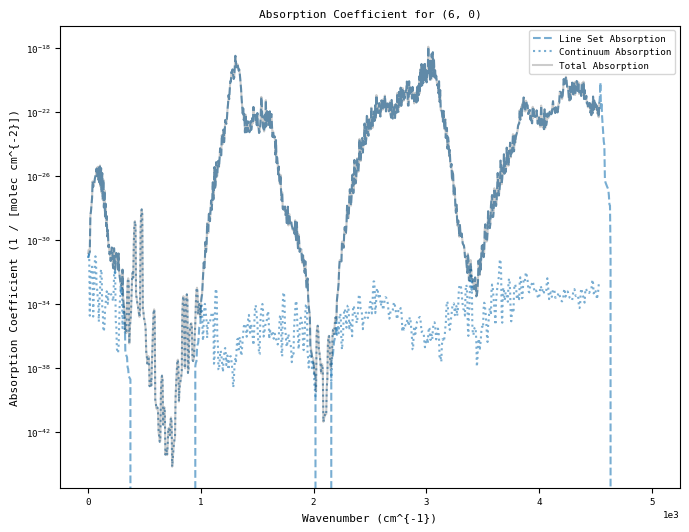

In [5]:
# Define a set of wavelengts to calculate absorption coefficient at and then plot them #

#waves = np.linspace(2800, 3800, 1000, dtype=float)
#waves = np.linspace(2000, 3000, 1000, dtype=float)
waves = np.linspace(0, 5000, 1000, dtype=float)
#waves = np.linspace(10.1, 10000, 1000, dtype=float)
k_abs = np.zeros((2,waves.shape[0]), dtype=float)
line_data.add_monochromatic_absorption(waves, 100, 1, out=k_abs, include_lines=True, include_continuum = True)

marker_style = dict(
	#marker = 'x',
	marker='none',
	markersize = 3,
)


if k_abs.ndim == 2:
	lines = plt.plot(waves, k_abs[0], alpha=0.6, ls='--', label='Line Set Absorption', **marker_style)
	plt.plot(waves, k_abs[1], alpha=0.6, color=lines[0].get_color(), ls=':', label='Continuum Absorption', **marker_style)
elif k_abs.ndim == 3:
	for i in range(k_abs.shape[1]):
		lines = plt.plot(waves, k_abs[0,i], alpha=0.6, ls='--', label=f'Line Set Absorption isot {i}', **marker_style)
		plt.plot(waves, k_abs[1,i], alpha=0.6, color=lines[0].get_color(), ls=':', label=f'Continuum Absorption iso {i}', **marker_style)

k_abs_total = np.sum(k_abs, axis=tuple(range(0,k_abs.ndim-1)) if k_abs.ndim!=1 else None)
plt.plot(waves, k_abs_total, color='black', alpha=0.2, ls='-', label=f'Total Absorption', **marker_style)

print(f'{np.min(waves)=} {np.max(waves)=}')
print(f'{np.min(k_abs)=} {np.max(k_abs)=}')
plt.title(f'Absorption Coefficient for ({line_data.ID}, {line_data.ISO})')
plt.xlabel('Wavenumber (cm^{-1})')
plt.ylabel('Absorption Coefficient (1 / [molec cm^{-2}])')
plt.yscale('log')
plt.legend()
plt.show()
plt.close()

#102834989206896,

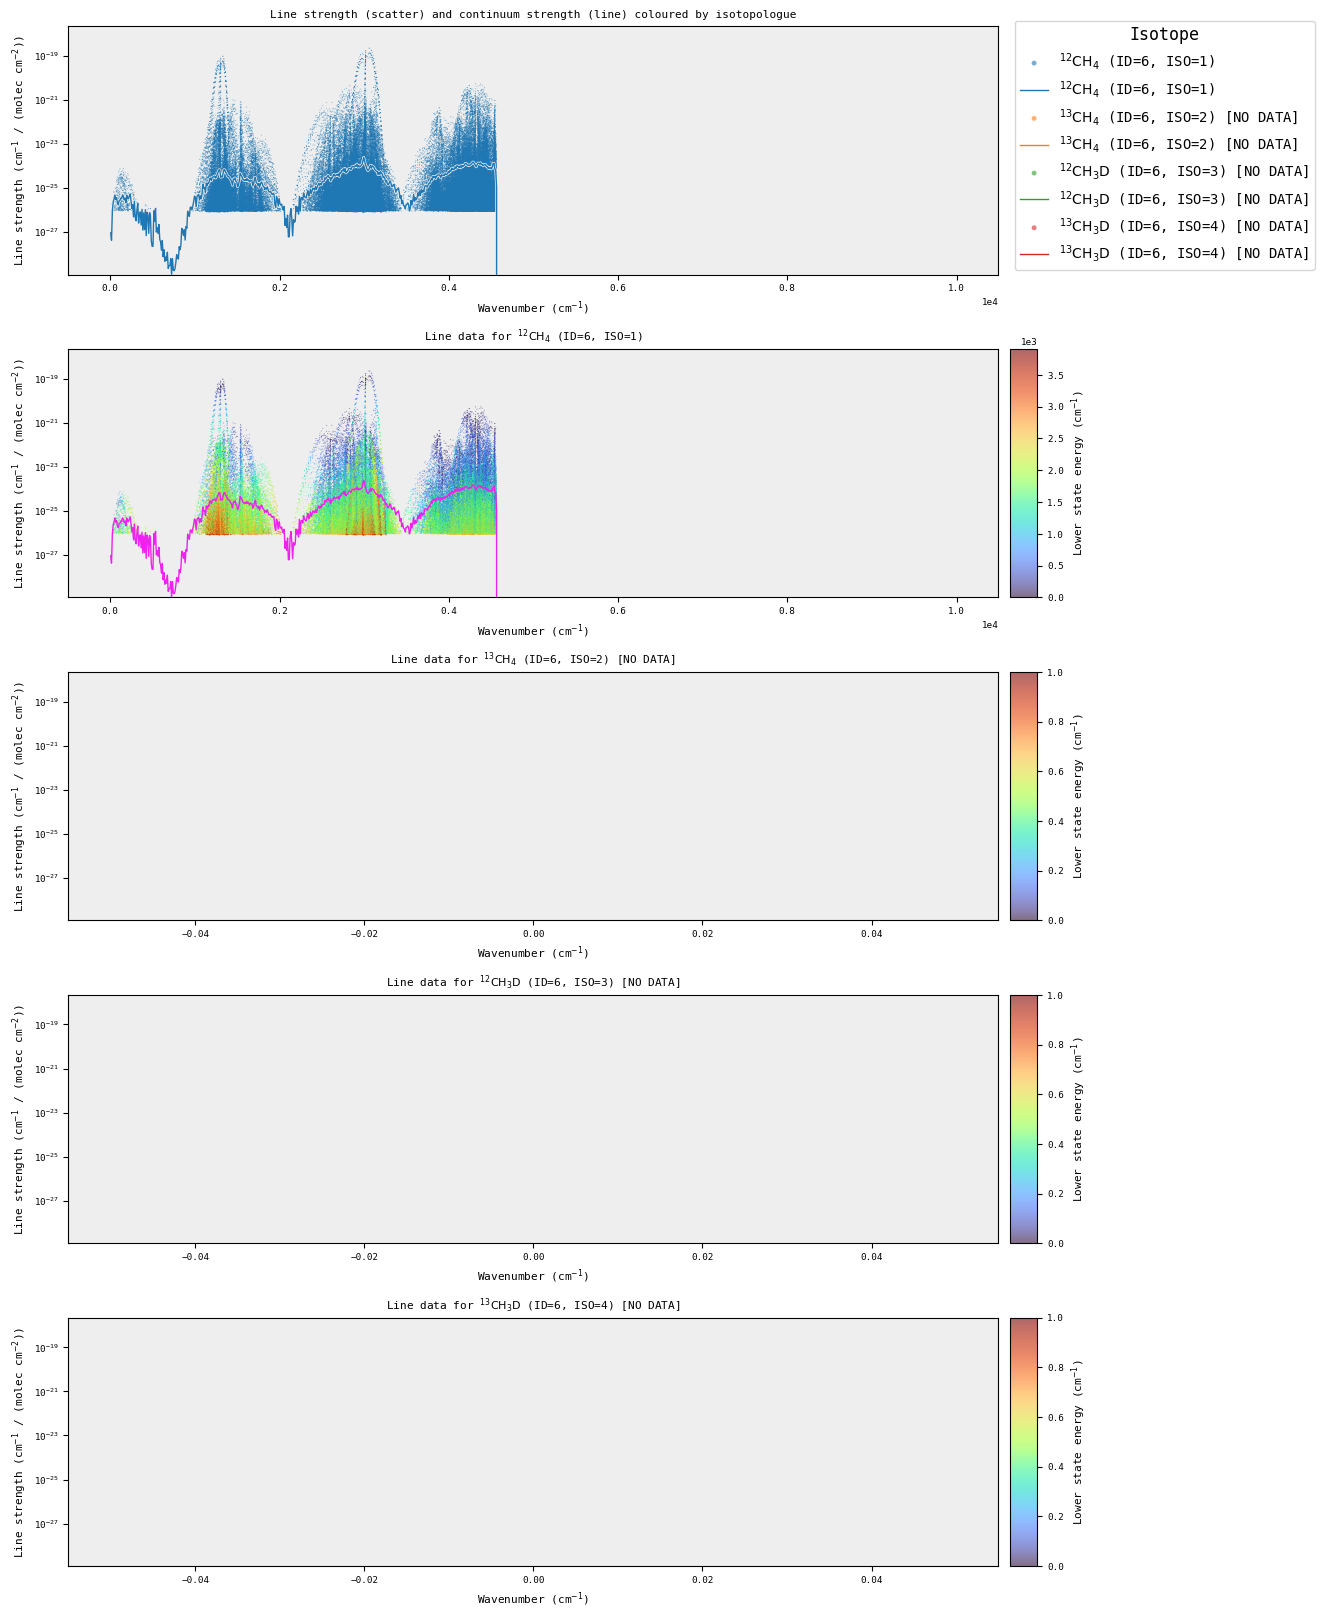

In [6]:
# Create example plot #

line_data.plot_linedata()